In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

In [4]:
#Loading phot.dat from the extracted file of blg-0003.tar.gz
column_labels = ['time(days)', 'magnitude', 'error_bar', 'seeing', 'sky', 'quality']
archive_data = pd.read_csv('phot.dat', sep=r'\s+', names=column_labels, engine='python')

print("Archive Loaded.")
print(archive_data.head())

Archive Loaded.
     time(days)  magnitude  error_bar  seeing     sky  quality
0  2.457791e+06     17.706      0.020    5.37   559.0      NaN
1  2.457791e+06     17.744      0.033    4.22  2761.0      NaN
2  2.457792e+06     17.670      0.017    4.72   479.0      NaN
3  2.457793e+06     17.750      0.023    5.65   677.0      NaN
4  2.457794e+06     17.661      0.019    4.56   714.0      NaN


## Astronomical Time (HJD)

Your `time(days)` column has values like 2.457791e+06. That is approximately 2.4 million days. Astronomers use Heliocentric Julian Dates (HJD), which count the number of days since January 1st, 4713 BC. If we feed a 2.4-million-day timeline to your solver, its math will break. We need to anchor the timeline to start at Day 0.

## Magnitude vs. Magnification

Your `magnitude` column is sitting around 17.7. In astronomy, the magnitude scale is inverted: a lower number means a brighter star. However, your `paczynski_curve` formula calculates magnification ($A$), where the baseline is 1 and a higher number means a brighter star. We have to convert magnitude ($m$) into magnification ($A$) using the standard flux-ratio formula:

$$
A = 10^{\frac{m_0 - m}{2.5}}
$$

(Where $m_0$ is the baseline, dimmest magnitude of the star before the rogue planet passed by.)

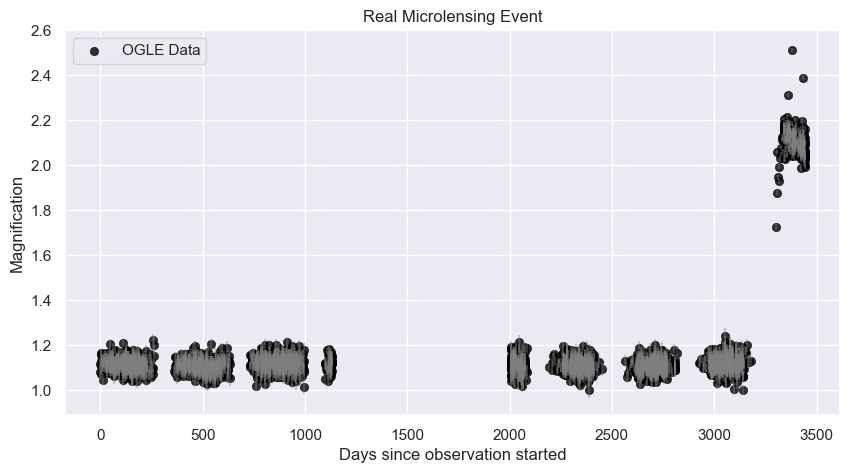

In [9]:
#Shift the Julian time so it starts from 0
start_time = archive_data['time(days)'].min()
time_clean = archive_data['time(days)'] - start_time

#Find the baseline brightness(more dimmer, more value)
baseline_mag = archive_data['magnitude'].max()

#Convert backward Magnitude into forward Magnification (A)
magnification_clean = 10**((baseline_mag - archive_data['magnitude'])/2.5)

plt.figure(figsize=(10,5))
#actual data points
sns.scatterplot(x=time_clean,y=magnification_clean,color="black",alpha=0.8,edgecolor=None,label="OGLE Data")
plt.errorbar(x=time_clean,y=magnification_clean,yerr=archive_data['error_bar'],fmt='none',color='gray',alpha=0.4)

plt.xlabel("Days since observation started")
plt.ylabel("Magnification")
plt.title("Real Microlensing Event")
plt.legend()
plt.show()